# 01 · Data validation: does the synthetic network look like the one we calibrated?

Feature 1 generates 6M card purchases over 24 months for a fictional Colombian four-party
network. This notebook checks the output against the anchors it was calibrated to and looks
at the structure the later features rely on: seasonality, fraud, merchant concentration and
the cardholder-merchant graph.

> **Synthetic data.** Every figure follows from `config/*.yaml` and `docs/assumptions.md`.
> Matching the anchors proves the generator is consistent with its assumptions, not that it
> describes the real market. Run `python -m ips.data_gen.generate` first.

In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter

from ips.data_gen.diagnostics import (
    bipartite_modularity,
    edge_list,
    leiden_partition,
    normalized_mutual_info,
    top_share,
)
from ips.data_gen.interchange_table import build_interchange_table
from ips.economics.simple_pnl import compute_pnl, pnl_by
from ips.utils.config import load_config, resolve_path

pl.Config.set_thousands_separator(",")
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(140)
pl.Config.set_fmt_str_lengths(60)
start = time.perf_counter()
cfg = load_config()
raw = resolve_path(cfg.output.raw_dir)

Chart style: the dataviz reference palette on a light surface. Thin marks, hairline
solid grid, text in ink (never in the series colour), one axis per chart, and categorical
colours in a fixed order (validated for colour-vision deficiency).

In [2]:
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.axisbelow": True,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": AXIS,
        "ytick.color": AXIS,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "legend.frameon": False,
        "legend.labelcolor": INK_2,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
    }
)


def compact(value, _pos=None):
    """1,234 -> 1.23k; 5,600,000 -> 5.6M."""
    for threshold, suffix in ((1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(value) >= threshold:
            return f"{value / threshold:,.3g}{suffix}"
    return f"{value:,.0f}"


def pretty(name):
    return str(name).replace("_", " ").capitalize()


def text_on(fill):
    """White or ink text, whichever contrasts more with the fill."""
    channels = [int(fill[i : i + 2], 16) / 255 for i in (1, 3, 5)]
    linear = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in channels]
    lum = 0.2126 * linear[0] + 0.7152 * linear[1] + 0.0722 * linear[2]
    return "#ffffff" if 1.05 / (lum + 0.05) >= (lum + 0.05) / 0.054 else INK

In [3]:
manifest = json.loads((raw / "manifest.json").read_text(encoding="utf-8"))
tx = pl.read_parquet(raw / "transactions.parquet")
cards = pl.read_parquet(raw / "cardholders.parquet")
merchants = pl.read_parquet(raw / "merchants.parquet")
issuers = pl.read_parquet(raw / "issuers.parquet")
print(
    f"seed {manifest['seed']} | config {manifest['config_hash']} | "
    f"{manifest['date_range'][0]} to {manifest['date_range'][1]} | "
    f"generated in {manifest['elapsed_seconds']} s"
)
pl.DataFrame({"table": list(manifest["rows"]), "rows": list(manifest["rows"].values())})

seed 20260910 | config 93819e7caa5c761e | 2024-01-01 to 2025-12-31 | generated in 5.7 s


table,rows
str,i64
"""issuers""",10
"""acquirers""",7
"""merchants""","30,600"
"""cardholders""","150,000"
"""transactions""","6,000,000"
"""mccs""",33
"""interchange_table""",192


## 1. Calibration scorecard

Each row compares a generated statistic with the anchor it was calibrated to. Public
anchors: Superfinanciera (Reporte de Inclusión Financiera 2022), BanRep (Reporte de
Infraestructura Financiera 2026) and the ECB card fraud report (2023); the rest come from
the project spec.

In [4]:
credit = pl.col("product") != "debit"
years = dict(tx.group_by(pl.col("txn_date").dt.year()).len().iter_rows())
frauds = tx.filter(pl.col("fraud_flag"))


def fraud_rate(frame):
    return (frame["amount_cop"] * frame["fraud_flag"]).sum() / frame["amount_cop"].sum()


pnl = compute_pnl(tx, build_interchange_table(cfg), cfg.pricing)
totals = pnl.totals()
n_years = cfg.dates.n_days / 365.25
cnp_fraud = frauds.filter(pl.col("channel") == "cnp")["amount_cop"].sum()
xb_fraud = fraud_rate(tx.filter(pl.col("cross_border")))
checks = [
    (
        "Debit share of cards",
        (cards["product"] == "debit").mean(),
        0.70,
        0.78,
        "pct",
        "Superfinanciera 2022: 74%",
    ),
    (
        "Debit share of purchases",
        (tx["product"] == "debit").mean(),
        0.64,
        0.72,
        "pct",
        "Superfinanciera 2022: 68%",
    ),
    (
        "Average debit ticket (COP)",
        tx.filter(~credit)["amount_cop"].mean(),
        98_000,
        164_000,
        "cop",
        "Superfinanciera 2022 + inflation: ~131k",
    ),
    (
        "Average credit ticket (COP)",
        tx.filter(credit)["amount_cop"].mean(),
        183_000,
        305_000,
        "cop",
        "Superfinanciera 2022 + inflation: ~244k",
    ),
    (
        "Purchases per card per year",
        tx.height / cards.height / n_years,
        19,
        26,
        "num",
        "Superfinanciera 2022: 19-26",
    ),
    (
        "Purchase growth 2025 vs 2024",
        years[2025] / years[2024] - 1,
        0.14,
        0.24,
        "pct",
        "BanRep 2026 report: +19%",
    ),
    (
        "Cross-border share of purchases",
        tx["cross_border"].mean(),
        0.01,
        0.05,
        "pct",
        "Spec: low, premium-heavy",
    ),
    ("Fraud, share of value", fraud_rate(tx), 0.0005, 0.0015, "pct3", "Spec §1.6: 0.05-0.15%"),
    (
        "Card-not-present share of fraud value",
        cnp_fraud / frauds["amount_cop"].sum(),
        0.75,
        0.92,
        "pct",
        "ECB 2023: ~84%",
    ),
    (
        "Cross-border vs domestic fraud rate",
        xb_fraud / fraud_rate(tx.filter(~pl.col("cross_border"))),
        8,
        20,
        "x",
        "ECB 2023: ~14x",
    ),
    (
        "Acquirer margin, share of GDV",
        totals["acquirer_net_cop"] / totals["gdv_cop"],
        0.002,
        0.007,
        "pct2",
        "Spec §1.6: 0.2-0.7%",
    ),
]
formats = {
    "pct": "{:.1%}",
    "pct2": "{:.2%}",
    "pct3": "{:.3%}",
    "cop": "{:,.0f}",
    "num": "{:.1f}",
    "x": "{:.1f}x",
}
scorecard = pl.DataFrame(
    [
        {
            "metric": name,
            "observed": formats[kind].format(value),
            "accepted range": f"{formats[kind].format(low)} - {formats[kind].format(high)}",
            "anchor": anchor,
            "in range": "yes" if low <= value <= high else "NO",
        }
        for name, value, low, high, kind, anchor in checks
    ]
)
scorecard

metric,observed,accepted range,anchor,in range
str,str,str,str,str
"""Debit share of cards""","""73.8%""","""70.0% - 78.0%""","""Superfinanciera 2022: 74%""","""yes"""
"""Debit share of purchases""","""67.6%""","""64.0% - 72.0%""","""Superfinanciera 2022: 68%""","""yes"""
"""Average debit ticket (COP)""","""128,987""","""98,000 - 164,000""","""Superfinanciera 2022 + inflation: ~131k""","""yes"""
"""Average credit ticket (COP)""","""248,309""","""183,000 - 305,000""","""Superfinanciera 2022 + inflation: ~244k""","""yes"""
"""Purchases per card per year""","""20.0""","""19.0 - 26.0""","""Superfinanciera 2022: 19-26""","""yes"""
"""Purchase growth 2025 vs 2024""","""18.7%""","""14.0% - 24.0%""","""BanRep 2026 report: +19%""","""yes"""
"""Cross-border share of purchases""","""1.9%""","""1.0% - 5.0%""","""Spec: low, premium-heavy""","""yes"""
"""Fraud, share of value""","""0.073%""","""0.050% - 0.150%""","""Spec §1.6: 0.05-0.15%""","""yes"""
"""Card-not-present share of fraud value""","""83.1%""","""75.0% - 92.0%""","""ECB 2023: ~84%""","""yes"""


## 2. Who pays with what

Large banks issue most premium and commercial cards; fintechs issue almost only debit.

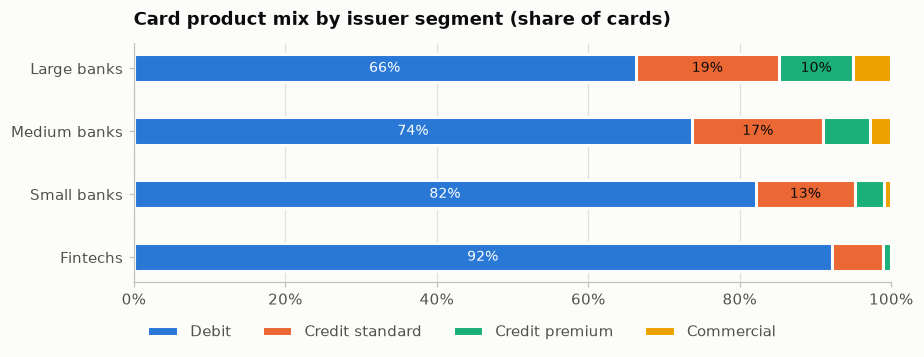

segment,debit,credit_standard,credit_premium,commercial
str,f64,f64,f64,f64
"""Large banks""",0.663,0.189,0.098,0.05
"""Medium banks""",0.737,0.173,0.061,0.028
"""Small banks""",0.822,0.13,0.039,0.009
"""Fintechs""",0.922,0.069,0.01,0.0


In [5]:
segment = (
    pl.when(pl.col("issuer_type") == "fintech")
    .then(pl.lit("Fintechs"))
    .otherwise(pl.concat_str([pl.col("size").str.to_titlecase(), pl.lit(" banks")]))
)
mix = (
    cards.join(issuers.select("issuer_id", "issuer_type", "size"), on="issuer_id")
    .with_columns(segment.alias("segment"), pl.col("product").cast(pl.Utf8))
    .group_by("segment", "product")
    .len()
    .with_columns((pl.col("len") / pl.col("len").sum().over("segment")).alias("share"))
)
order = ["Large banks", "Medium banks", "Small banks", "Fintechs"]
fig, ax = plt.subplots(figsize=(8.5, 3.4))
left = np.zeros(len(order))
for i, product in enumerate(cfg.products):
    shares = np.array(
        [
            mix.filter((pl.col("segment") == s) & (pl.col("product") == product))["share"].sum()
            for s in order
        ]
    )
    ax.barh(
        order,
        shares,
        left=left,
        height=0.45,
        color=SERIES[i],
        edgecolor=SURFACE,
        linewidth=2,
        label=pretty(product),
    )
    for y, (x0, width) in enumerate(zip(left, shares, strict=True)):
        if width >= 0.08:
            ax.text(
                x0 + width / 2,
                y,
                f"{width:.0%}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_on(SERIES[i]),
            )
    left += shares
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Card product mix by issuer segment (share of cards)")
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0, -0.12))
fig.tight_layout()
plt.show()
(
    mix.pivot(on="product", index="segment", values="share")
    .select("segment", *cfg.products)
    .fill_null(0.0)
    .join(pl.DataFrame({"segment": order}).with_row_index("position"), on="segment")
    .sort("position")
    .drop("position")
    .with_columns(cs.float().round(3))
)

## 3. Merchants: a few carry most of the volume

Merchant size is lognormal and cardholders return to their habitual merchants, so volume
concentrates. The curve ranks merchants by volume; the diagonal would be equal shares.

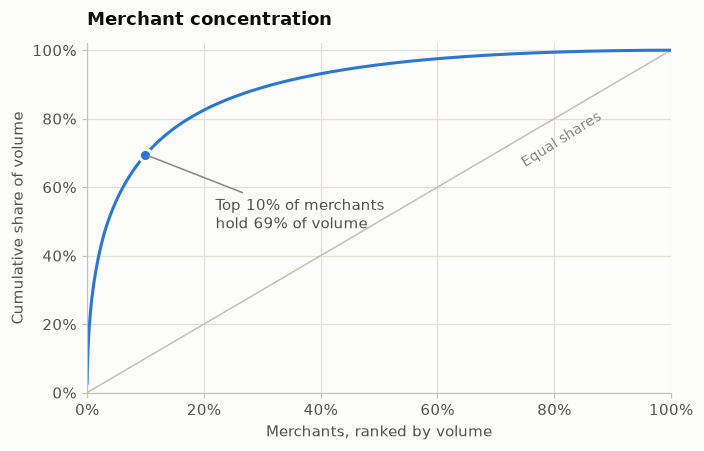

In [6]:
volume = np.sort(
    tx.group_by("merchant_id").agg(pl.col("amount_cop").sum())["amount_cop"].to_numpy()
)[::-1]
cumulative = np.cumsum(volume) / volume.sum()
ranked = np.arange(1, len(volume) + 1) / len(volume)
top10 = top_share(volume, 0.10)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1)
ax.text(0.74, 0.66, "Equal shares", color=MUTED, rotation=32, fontsize=9)
ax.plot(ranked, cumulative, color=SERIES[0])
ax.scatter([0.10], [top10], s=64, color=SERIES[0], edgecolors=SURFACE, linewidths=2, zorder=3)
ax.annotate(
    f"Top 10% of merchants\nhold {top10:.0%} of volume",
    xy=(0.10, top10),
    xytext=(0.22, 0.48),
    color=INK_2,
    arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 1},
)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Merchants, ranked by volume")
ax.set_ylabel("Cumulative share of volume")
ax.set_title("Merchant concentration")
fig.tight_layout()
plt.show()

## 4. Tickets by MCC group

Amounts are lognormal by MCC and scaled by card product. Dot = median, line = 10th to 90th
percentile; the axis is logarithmic because tickets span three orders of magnitude.

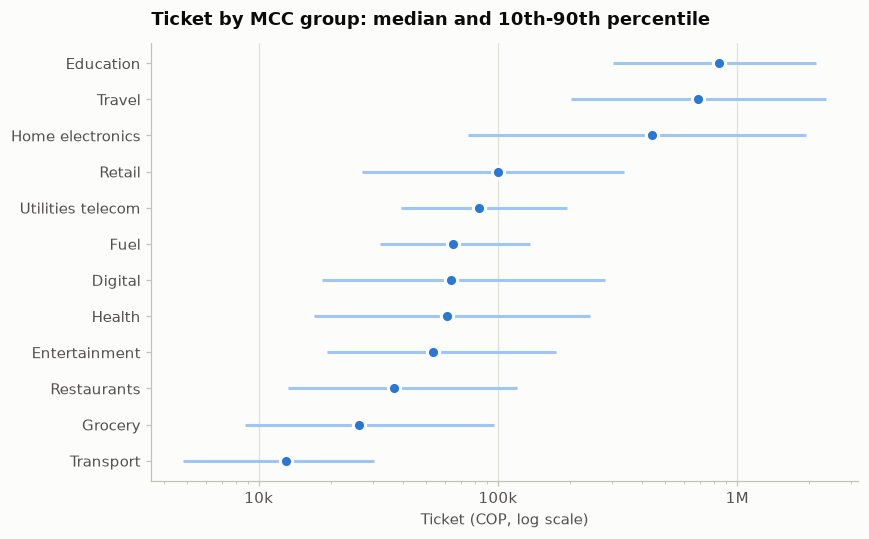

mcc_group,p10,median,p90,mean
enum,i64,i64,i64,i64
"""transport""","4,847","13,020","30,447","15,983"
"""grocery""","8,774","26,345","96,625","44,191"
"""restaurants""","13,271","36,617","119,700","56,549"
"""entertainment""","19,297","53,711","174,427","82,372"
"""health""","17,027","61,114","242,965","121,330"
"""digital""","18,442","63,808","280,017","122,040"
"""fuel""","32,237","64,647","135,856","77,085"
"""utilities_telecom""","39,386","83,370","193,931","105,355"
"""retail""","26,967","100,168","337,678","155,318"


In [7]:
tickets = (
    tx.group_by("mcc_group")
    .agg(
        pl.col("amount_cop").quantile(0.10).alias("p10"),
        pl.col("amount_cop").median().alias("median"),
        pl.col("amount_cop").quantile(0.90).alias("p90"),
        pl.col("amount_cop").mean().round(0).alias("mean"),
    )
    .sort("median")
)
y = np.arange(tickets.height)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(y, tickets["p10"], tickets["p90"], color=BLUES[1], linewidth=2)
ax.scatter(tickets["median"], y, s=64, color=SERIES[0], edgecolors=SURFACE, linewidths=2, zorder=3)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(compact))
ax.set_yticks(y, [pretty(g) for g in tickets["mcc_group"]])
ax.grid(axis="y", visible=False)
ax.set_xlabel("Ticket (COP, log scale)")
ax.set_title("Ticket by MCC group: median and 10th-90th percentile")
fig.tight_layout()
plt.show()
tickets.with_columns(cs.numeric().round(0).cast(pl.Int64))

## 5. Seasonality and growth

Daily activity combines a month factor (December peak, June bonus), a +19% annual trend
(BanRep), payday boosts on the 1st, 14th-16th and 29th-31st, and a weekday profile per
MCC group.

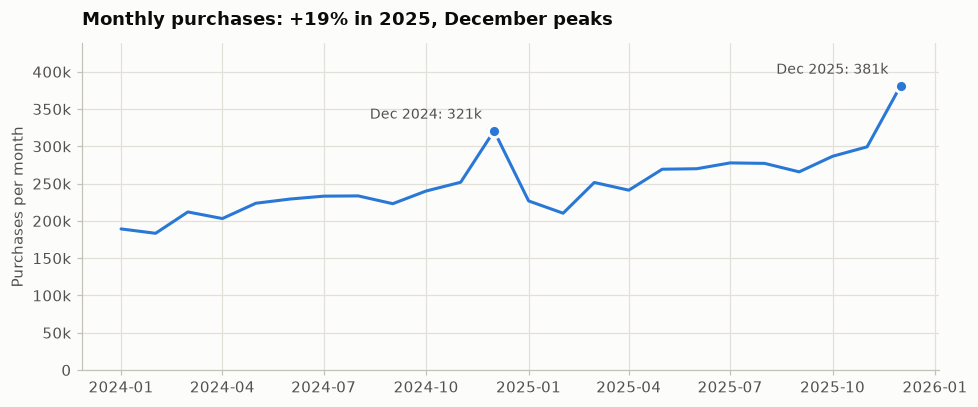

In [8]:
monthly = tx.group_by(pl.col("txn_date").dt.truncate("1mo").alias("month")).len().sort("month")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(monthly["month"], monthly["len"], color=SERIES[0])
december = monthly.filter(pl.col("month").dt.month() == 12)
ax.scatter(
    december["month"],
    december["len"],
    s=64,
    color=SERIES[0],
    edgecolors=SURFACE,
    linewidths=2,
    zorder=3,
)
for month, count in december.iter_rows():
    ax.annotate(
        f"{month:%b %Y}: {compact(count)}",
        xy=(month, count),
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        color=INK_2,
        fontsize=9,
    )
ax.yaxis.set_major_formatter(FuncFormatter(compact))
ax.set_ylim(0, monthly["len"].max() * 1.15)
ax.set_ylabel("Purchases per month")
ax.set_title(f"Monthly purchases: +{years[2025] / years[2024] - 1:.0%} in 2025, December peaks")
fig.tight_layout()
plt.show()

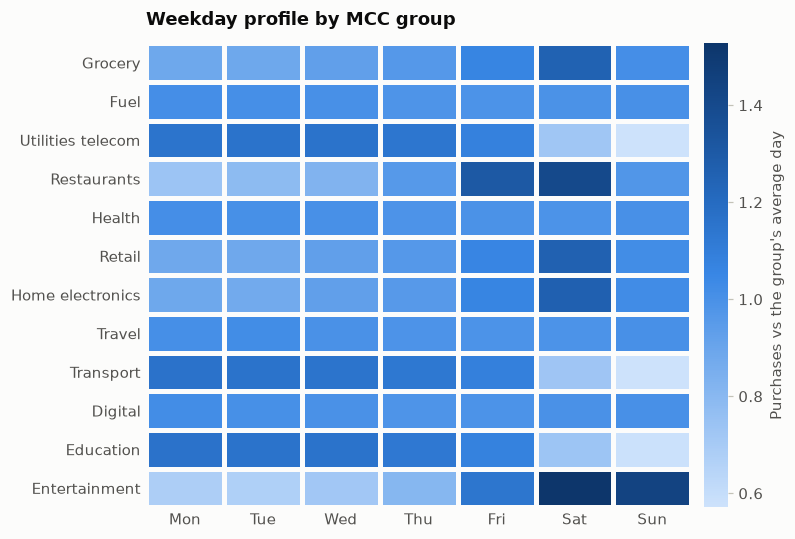

In [9]:
weekday = (
    tx.group_by("mcc_group", pl.col("txn_date").dt.weekday().alias("weekday"))
    .len()
    .with_columns((pl.col("len") / pl.col("len").mean().over("mcc_group")).alias("index"))
    .with_columns(pl.col("mcc_group").cast(pl.Utf8))
    .pivot(on="weekday", index="mcc_group", values="index", sort_columns=True)
)
groups = [g for g in cfg.group_names]
matrix = np.array([weekday.filter(pl.col("mcc_group") == g).row(0)[1:] for g in groups])
fig, ax = plt.subplots(figsize=(7.5, 5))
mesh = ax.pcolormesh(
    matrix, cmap=LinearSegmentedColormap.from_list("blues", BLUES), edgecolors=SURFACE, linewidth=2
)
ax.set_xticks(np.arange(7) + 0.5, ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_yticks(np.arange(len(groups)) + 0.5, [pretty(g) for g in groups])
ax.invert_yaxis()
ax.grid(False)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
bar = fig.colorbar(mesh, ax=ax, pad=0.02)
bar.outline.set_visible(False)
bar.set_label("Purchases vs the group's average day", color=INK_2)
ax.set_title("Weekday profile by MCC group")
fig.tight_layout()
plt.show()

## 6. Channel, cross-border and fraud

Card-not-present purchases are a minority of the value but carry most of the fraud, and
cross-border purchases defraud far more often than domestic ones: the structure reported by
the ECB, which the fraud parameters were calibrated to reproduce.

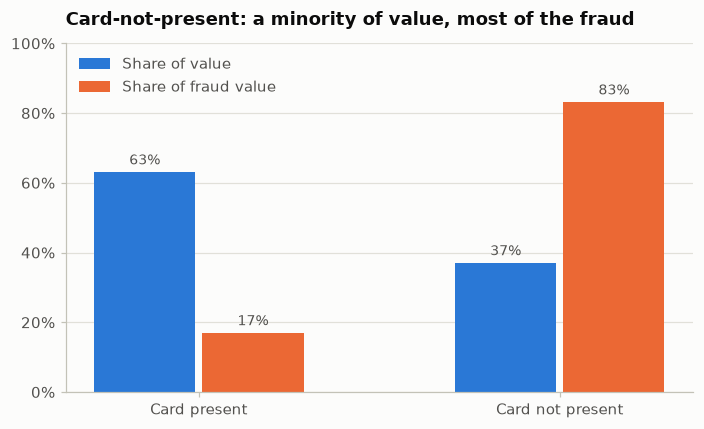

In [10]:
by_channel = (
    tx.group_by("channel")
    .agg(
        pl.col("amount_cop").sum().alias("gdv"),
        (pl.col("amount_cop") * pl.col("fraud_flag")).sum().alias("fraud_value"),
    )
    .with_columns(
        (pl.col("gdv") / pl.col("gdv").sum()).alias("share of value"),
        (pl.col("fraud_value") / pl.col("fraud_value").sum()).alias("share of fraud value"),
        pl.col("channel").cast(pl.Utf8),
    )
    .sort("channel", descending=True)
)
labels = {"cp": "Card present", "cnp": "Card not present"}
x = np.arange(by_channel.height)
fig, ax = plt.subplots(figsize=(6.5, 4))
for i, column in enumerate(["share of value", "share of fraud value"]):
    bars = ax.bar(
        x + (i - 0.5) * 0.3,
        by_channel[column],
        width=0.28,
        color=SERIES[i],
        label=column.capitalize(),
    )
    ax.bar_label(
        bars, labels=[f"{v:.0%}" for v in by_channel[column]], padding=3, color=INK_2, fontsize=9
    )
ax.set_xticks(x, [labels[c] for c in by_channel["channel"]])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.grid(axis="x", visible=False)
ax.set_title("Card-not-present: a minority of value, most of the fraud")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

In [11]:
fraud_table = (
    tx.group_by(pl.col("channel").cast(pl.Utf8), "cross_border")
    .agg(
        pl.len().alias("purchases"),
        pl.col("fraud_flag").mean().alias("fraud rate (count)"),
        ((pl.col("amount_cop") * pl.col("fraud_flag")).sum() / pl.col("amount_cop").sum()).alias(
            "fraud rate (value)"
        ),
        pl.col("chargeback_flag").mean().alias("chargeback rate"),
    )
    .sort("channel", "cross_border", descending=[True, False])
)
fraud_table.with_columns(cs.float().round(5))

channel,cross_border,purchases,fraud rate (count),fraud rate (value),chargeback rate
str,bool,u32,f64,f64,f64
"""cp""",false,"4,547,675",0.00016,0.00019,0.00053
"""cp""",true,"12,893",0.0014,0.00102,0.00202
"""cnp""",false,"1,339,455",0.001,0.00098,0.00208
"""cnp""",true,"99,977",0.00718,0.00716,0.00744


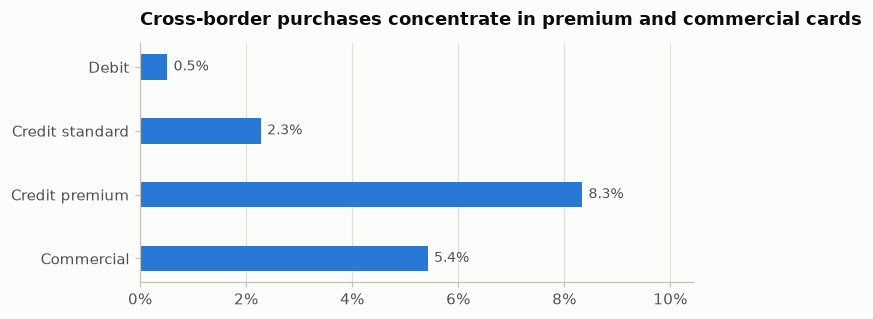

In [12]:
xb = tx.group_by(pl.col("product").cast(pl.Utf8)).agg(
    pl.col("cross_border").mean().alias("cross-border share")
)
xb = xb.join(pl.DataFrame({"product": list(cfg.products)}).with_row_index("order"), on="product")
xb = xb.sort("order")
fig, ax = plt.subplots(figsize=(6.5, 3))
bars = ax.barh(
    [pretty(p) for p in xb["product"]], xb["cross-border share"], height=0.4, color=SERIES[0]
)
ax.bar_label(
    bars, labels=[f"{v:.1%}" for v in xb["cross-border share"]], padding=4, color=INK_2, fontsize=9
)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlim(0, xb["cross-border share"].max() * 1.25)
ax.grid(axis="y", visible=False)
ax.set_title("Cross-border purchases concentrate in premium and commercial cards")
fig.tight_layout()
plt.show()

## 7. On-us is what independence predicts

Acquirers are assigned to merchants without looking at cardholders' issuers, so the on-us
rate should equal the sum over bank groups of (issuer share x acquirer share).

In [13]:
issuer_group = dict(issuers.select("issuer_id", "bank_group").iter_rows())
acquirers = pl.read_parquet(raw / "acquirers.parquet")
acquirer_group = dict(acquirers.select("acquirer_id", "bank_group").iter_rows())
grouped = tx.select(
    pl.col("issuer_id")
    .cast(pl.Utf8)
    .replace_strict(issuer_group, return_dtype=pl.Utf8)
    .alias("issuer_group"),
    pl.col("acquirer_id")
    .cast(pl.Utf8)
    .replace_strict(acquirer_group, return_dtype=pl.Utf8)
    .alias("acquirer_group"),
    "on_us",
)
share = {
    side: dict(grouped.group_by(side).len().with_columns(pl.col("len") / tx.height).iter_rows())
    for side in ("issuer_group", "acquirer_group")
}
expected = sum(
    p * share["acquirer_group"].get(g, 0.0)
    for g, p in share["issuer_group"].items()
    if g is not None
)
pl.DataFrame(
    {
        "on-us rate": ["observed", "expected under independence"],
        "value": [grouped["on_us"].mean(), expected],
    }
).with_columns(cs.float().round(4))

on-us rate,value
str,f64
"""observed""",0.1073
"""expected under independence""",0.1078


## 8. The cardholder-merchant graph

Degrees are long-tailed: most cardholders buy from a handful of merchants, while a few
merchants reach thousands of cardholders. Communities were **planted** by the generator
(home city x latent lifestyle segment and merchant clientele); the table checks that
Leiden recovers them from the edges alone, on a 20% sample of cardholders.

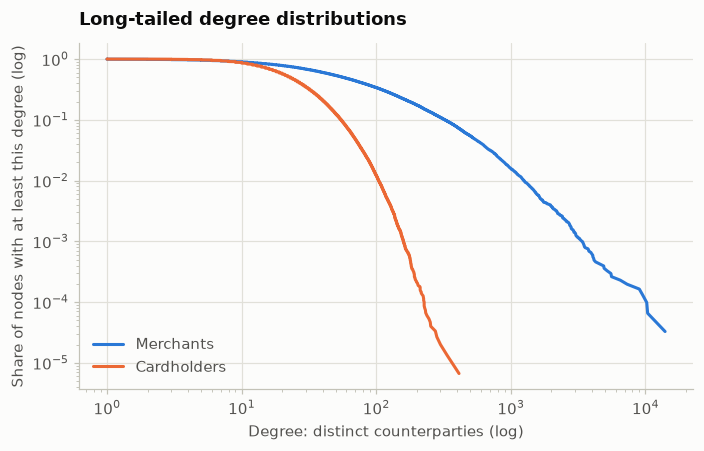

4,269,259 distinct cardholder-merchant pairs, mean weight 1.41


In [14]:
edges = edge_list(tx)


def ccdf(values):
    ordered = np.sort(values)
    return ordered, 1.0 - np.arange(len(ordered)) / len(ordered)


merchant_degree = edges.group_by("merchant_id").len()["len"].to_numpy()
card_degree = edges.group_by("cardholder_id").len()["len"].to_numpy()
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(*ccdf(merchant_degree), color=SERIES[0], label="Merchants")
ax.loglog(*ccdf(card_degree), color=SERIES[1], label="Cardholders")
ax.set_xlabel("Degree: distinct counterparties (log)")
ax.set_ylabel("Share of nodes with at least this degree (log)")
ax.set_title("Long-tailed degree distributions")
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()
print(
    f"{edges.height:,} distinct cardholder-merchant pairs, mean weight {edges['weight'].mean():.2f}"
)

In [15]:
sample = cards.sample(fraction=0.2, seed=cfg.seed)["cardholder_id"]
sample_edges = edges.filter(pl.col("cardholder_id").is_in(sample.implode()))
latent = (
    pl.read_parquet(raw / "latent" / "merchants_latent.parquet")
    .join(merchants.select("merchant_id", "city", "mcc_group"), on="merchant_id")
    .with_columns(pl.col("city").cast(pl.Utf8).fill_null("online"))
    .with_columns(
        pl.concat_str([pl.col("city"), pl.col("clientele").cast(pl.Utf8)], separator="|").alias(
            "planted"
        )
    )
)
rows = []
for resolution in (1.0, 2.0, 4.0):
    card_comm, merchant_comm = leiden_partition(sample_edges, seed=cfg.seed, resolution=resolution)
    labelled = merchant_comm.join(latent, on="merchant_id")
    rows.append(
        {
            "resolution": resolution,
            "communities": merchant_comm["community"].n_unique(),
            "modularity": bipartite_modularity(sample_edges, card_comm, merchant_comm),
            **{
                f"NMI vs {column}": normalized_mutual_info(labelled["community"], labelled[column])
                for column in ("planted", "city", "clientele", "mcc_group")
            },
        }
    )
pl.DataFrame(rows).with_columns(cs.float().round(3))

resolution,communities,modularity,NMI vs planted,NMI vs city,NMI vs clientele,NMI vs mcc_group
f64,i64,f64,f64,f64,f64,f64
1.0,13,0.54,0.519,0.756,0.001,0.002
2.0,47,0.493,0.583,0.588,0.209,0.031
4.0,247,0.366,0.383,0.388,0.072,0.036


At resolution 1 the communities are essentially cities. At resolution 2 the latent
clientele appears inside them, and the communities agree with clientele far more than with
the MCC group: merchants that share customers are grouped across categories. That is the
hypothesis Feature 4 has to turn into better business metrics than a k-means on observable
attributes, and report honestly if it does not.

## 9. P&L sanity check

The transitional P&L prices every purchase with the interchange table and splits the blended
MDR among issuer, network and acquirer. The conservation invariant must hold on 6M rows.

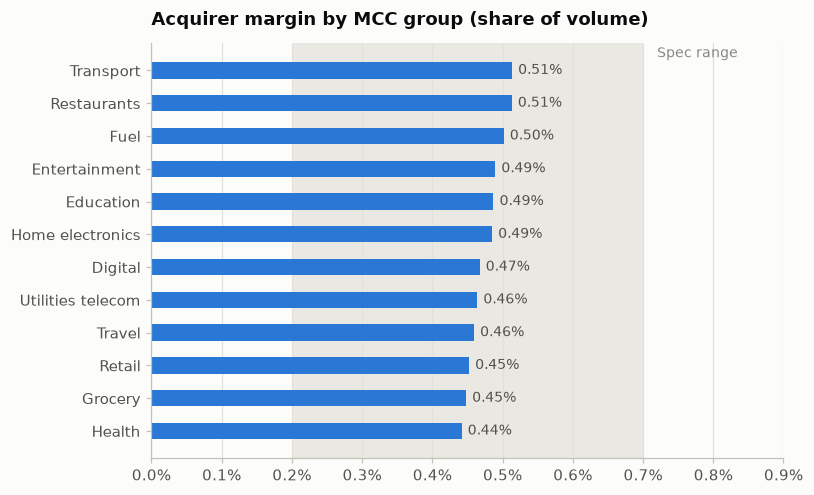

Conservation gap: 3.81e-06 COP on 21,472,113,499 COP of MDR


In [16]:
gap = (
    totals["interchange_cop"]
    + totals["scheme_fee_cop"]
    + totals["acquirer_net_cop"]
    - totals["mdr_cop"]
)
assert abs(gap) <= 1e-9 * totals["mdr_cop"], gap
margins = pnl_by(pnl, ["mcc_group"]).sort("acquirer_margin_rate")
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.axvspan(0.002, 0.007, color=GRID, alpha=0.7, linewidth=0)
ax.text(0.0072, margins.height - 0.6, "Spec range", color=MUTED, fontsize=9)
bars = ax.barh(
    [pretty(g) for g in margins["mcc_group"]],
    margins["acquirer_margin_rate"],
    height=0.5,
    color=SERIES[0],
)
ax.bar_label(
    bars,
    labels=[f"{v:.2%}" for v in margins["acquirer_margin_rate"]],
    padding=4,
    color=INK_2,
    fontsize=9,
)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.set_xlim(0, 0.009)
ax.grid(axis="y", visible=False)
ax.set_title("Acquirer margin by MCC group (share of volume)")
fig.tight_layout()
plt.show()
print(f"Conservation gap: {gap:.2e} COP on {totals['mdr_cop']:,.0f} COP of MDR")

In [17]:
elapsed = time.perf_counter() - start
print(
    f"Network revenue (scheme fees) = {pnl.network_revenue:,.0f} COP over {tx.height:,} "
    f"purchases | net revenue yield = {totals['net_revenue_yield_bps']:.1f} bps on GDV of "
    f"{totals['gdv_cop']:,.0f} COP"
)
print(f"Notebook runtime: {elapsed:.1f} s")

Network revenue (scheme fees) = 1,307,886,180 COP over 6,000,000 purchases | net revenue yield = 13.0 bps on GDV of 1,006,066,292,469 COP
Notebook runtime: 61.5 s


## Limits

- The scorecard shows the generator reproduces the anchors it was calibrated to. That is a
  consistency check, not evidence about the real Colombian market.
- The communities were planted. Feature 4 must show that detecting them improves business
  metrics over a k-means on observable attributes, not just that they exist.
- Interchange cells are own assumptions within the spec's ranges, pending comparison with
  the tables Mastercard and Redeban publish in Colombia.
- The network yield is 13 bps by construction (a single percentage scheme fee) until
  Feature 3 adds cross-border and authorisation fees and issuer costs.